In [5]:
%pip install seaborn

first 5 records:
    Age  EstimatedSalary  Purchased
0   19            19000          0
1   35            20000          0
2   26            43000          0
3   27            57000          0
4   19            76000          0

 null values Age                0
EstimatedSalary    0
Purchased          0
dtype: int64
first 5 records
 [[ 0.58164944 -0.88670699]
 [-0.60673761  1.46173768]
 [-0.01254409 -0.5677824 ]
 [-0.60673761  1.89663484]
 [ 1.37390747 -1.40858358]]
first 5 records
 [[-0.80480212  0.50496393]
 [-0.01254409 -0.5677824 ]
 [-0.30964085  0.1570462 ]
 [-0.80480212  0.27301877]
 [-0.30964085 -0.5677824 ]]
result of CM [[62  6]
 [ 4 28]]

result of Accu 90.0
New Prediction: [0 0]


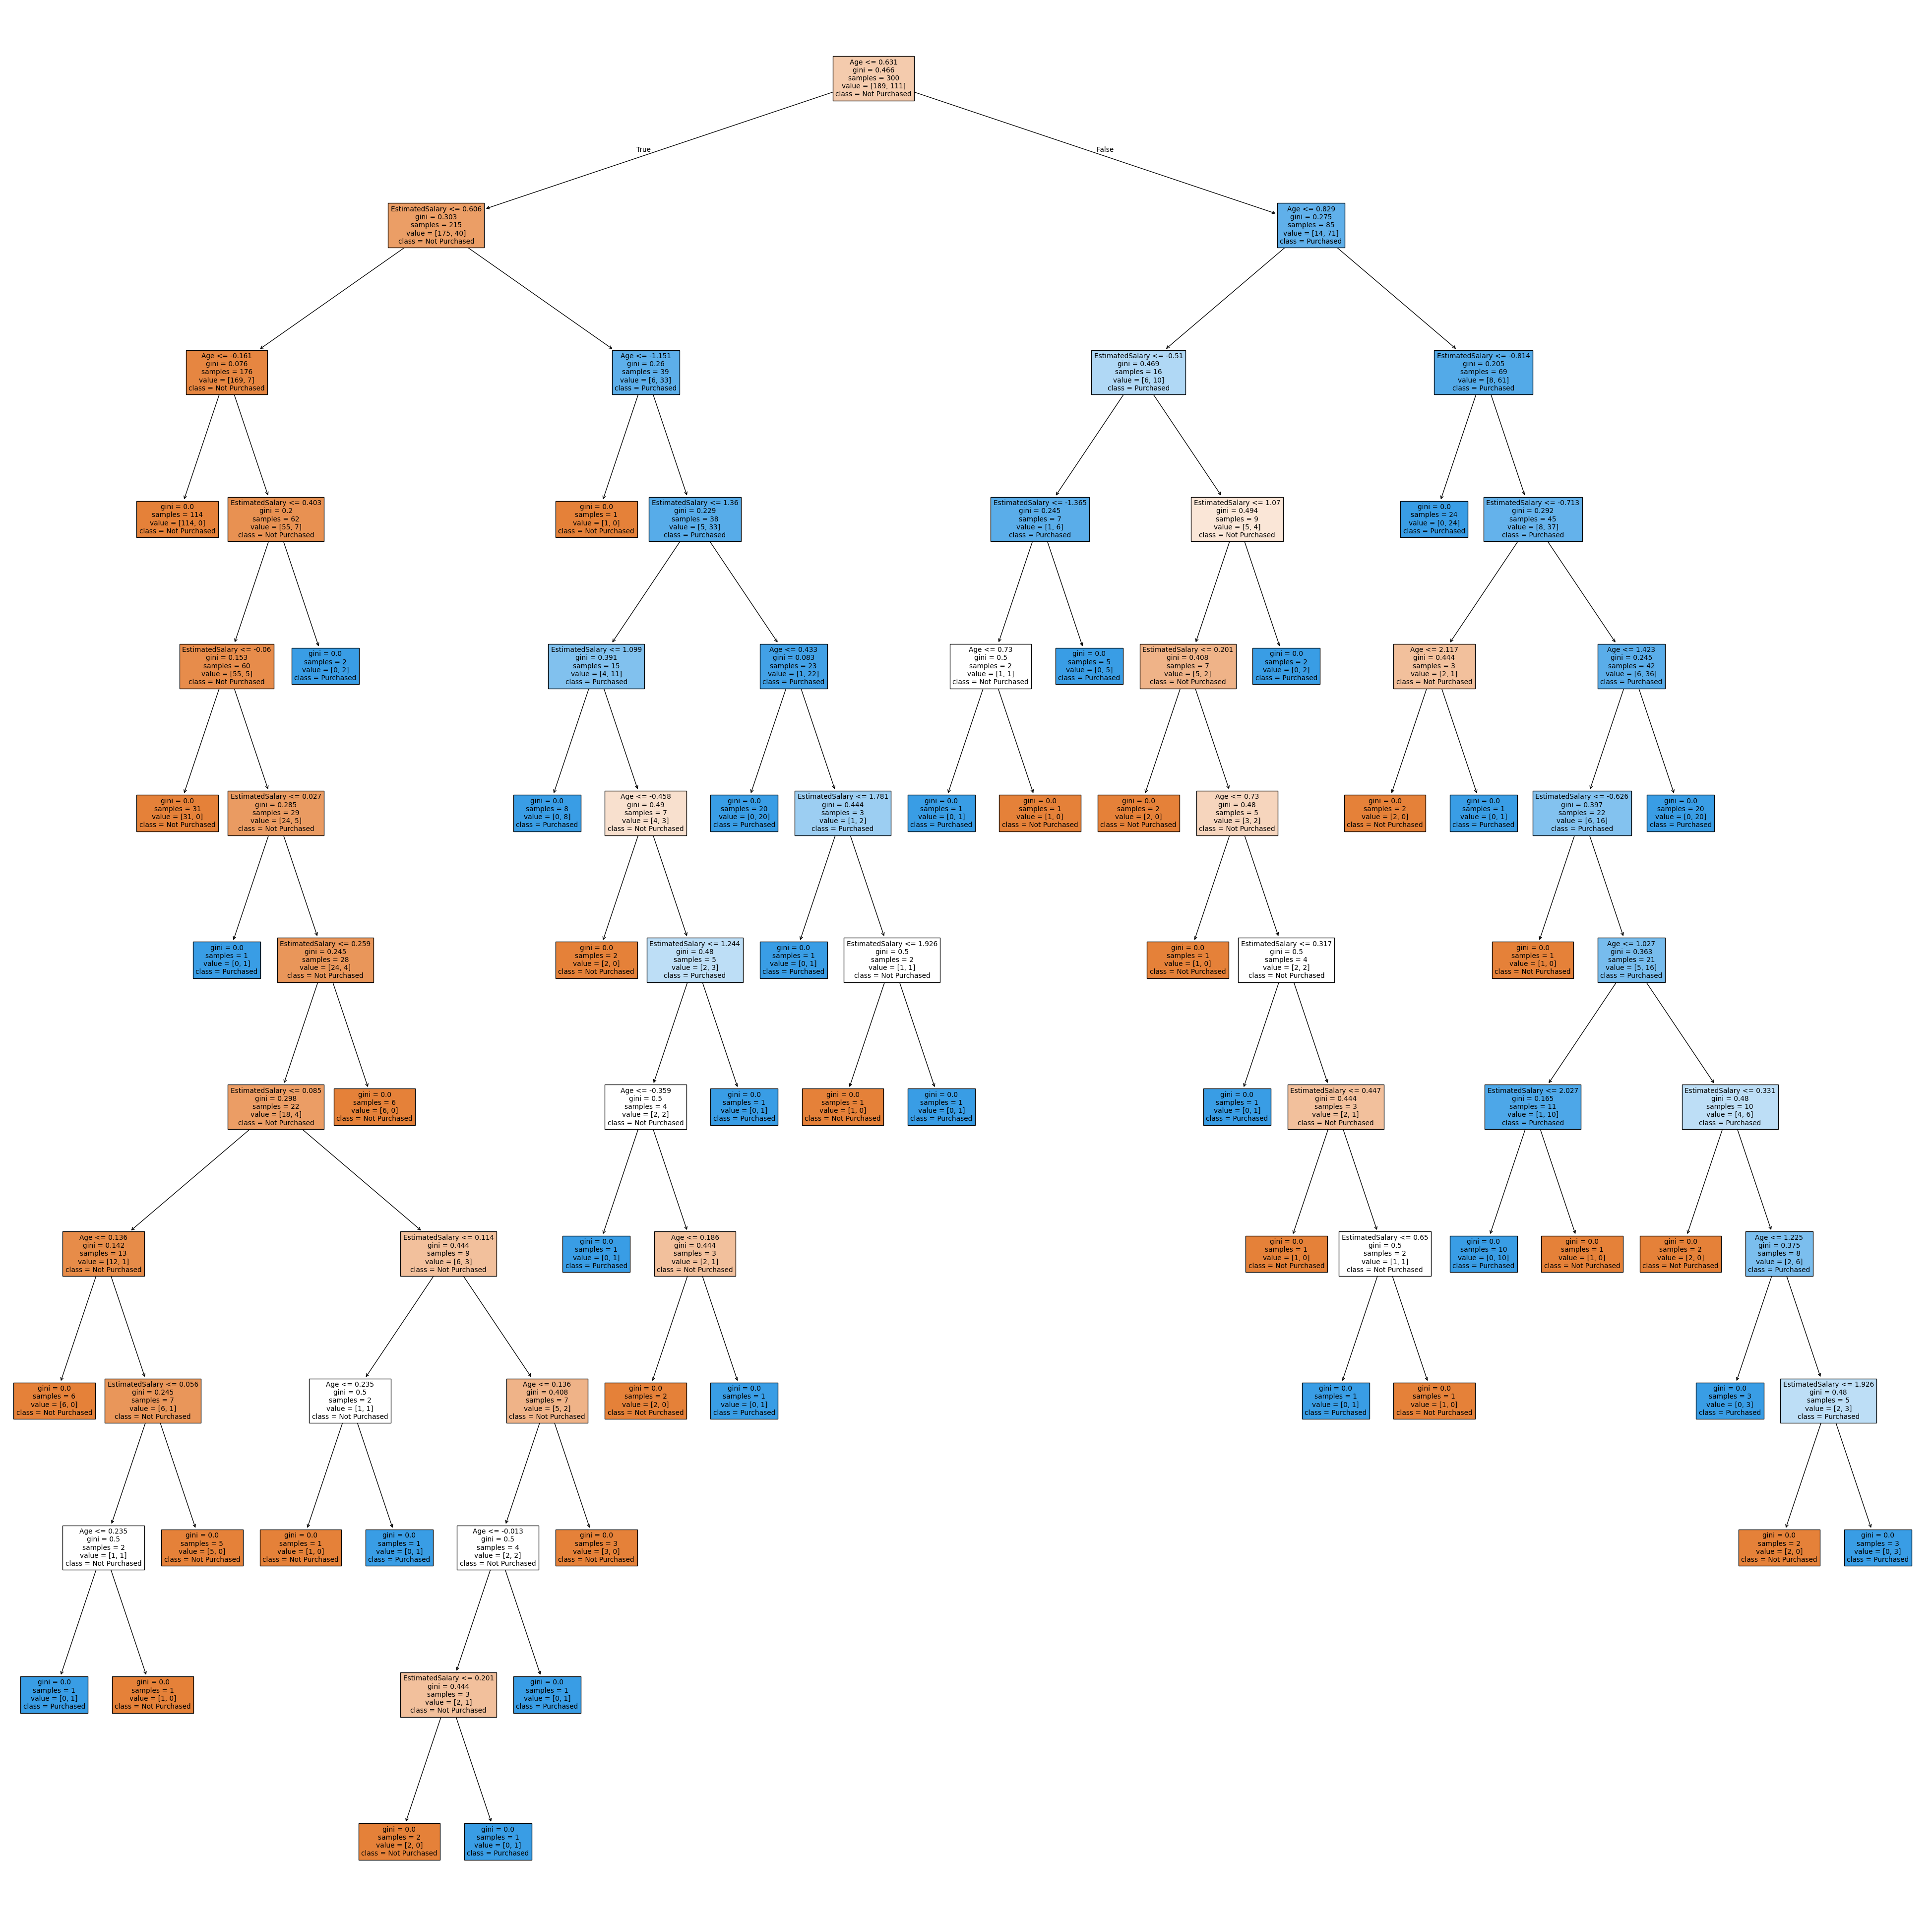

In [9]:
#based on social network train model using DT with CART 
#step1 import lib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as srs
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score 
#step2 reading dataset
dataset=pd.read_csv("Social_Network_Ads.csv")

#step3: check some samples
print("first 5 records:\n", dataset.head(5))

#step4: check nulls
print("\n null values", dataset.isnull().sum())

#step5: seperate x/y
X = dataset[["Age","EstimatedSalary"]].values
y = dataset["Purchased"].values

#step6: split data into train & test
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
#step7: feacture scaling
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)
#display
#show first 5 scaled value of x_train
print("first 5 records\n",x_train[:5])
#show first 5 scaled value of x_test
print("first 5 records\n",x_test[:5])

#step8 apply DTM (decision tree model)
dt=DecisionTreeClassifier(random_state=0)
dt.fit(x_train,y_train)
#step9: predict data using unseen 
y_pred=dt.predict(x_test)
#step10: confusion Mat and Accuracy
cm=confusion_matrix(y_test,y_pred)
print("result of CM",cm)
print("\nresult of Accu",dt.score(x_test,y_test)*100)
#step11 check
new_data=np.array([[19,19000],[35,20000]])
new_data = sc.transform(new_data)
print("New Prediction:", dt.predict(new_data))
#step12: plot decision tree
plt.figure(figsize=(50,50))
plot_tree(dt,
          feature_names=["Age", "EstimatedSalary"],
          class_names=["Not Purchased", "Purchased"],
          filled=True)

plt.savefig("demo.jpg")
plt.show()